1. Import the data and group the rows by star. np.loadtxt / np.genfromtxt / astropy.ascii.read — LEC2; check out CODING/ examples


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize

Gaia_Dataset = "gaia_m31_lcs.csv"

dt = [("source_id", "i8"), ("t_year", "f8"), ("gmag", "f8"), ("gmag_err", 'f8')]

df = np.genfromtxt(Gaia_Dataset, delimiter=',', names=True, dtype=dt)

df = df[np.lexsort((df["t_year"], df["source_id"]))]

ids, start, n = np.unique(df["source_id"], return_index=True, return_counts=True)
stars = {sid: df[s:s+k] for sid, s, k in zip(ids, start, n)}

# Sanity checks to make sure the file is correct
print(f"rows: {len(df):,}   (expect 92,590)")
print(f"stars: {len(ids):,}   (expect 2,025)")
print(f"epochs per star: min {n.min()}, median {int(np.median(n))}, max {n.max()}   (expect min >= 30)")
print(f"time range: {df['t_year'].min():.3f} - {df['t_year'].max():.3f}   (expect 2014.6 - 2017.4)")
print(f"G range: {df['gmag'].min():.2f} - {df['gmag'].max():.2f}   (expect < 17)")
print(f"median gmag_err: {1e3*np.median(df['gmag_err']):.2f} mmag")
print(f"NaNs: {sum(np.isnan(df[c]).sum() for c in ('t_year', 'gmag', 'gmag_err'))}")
print(f"non-positive errors: {(df['gmag_err'] <= 0).sum()}")

# Shared setup used by every later task
N = len(ids)
T0 = 2016.0
g_med = np.array([np.median(df["gmag"][a:a+k]) for a, k in zip(start, n)])
plt.style.use("default")


rows: 92,590   (expect 92,590)
stars: 2,025   (expect 2,025)
epochs per star: min 30, median 41, max 99   (expect min >= 30)
time range: 2014.645 - 2017.404   (expect 2014.6 - 2017.4)
G range: 8.26 - 17.30   (expect < 17)
median gmag_err: 2.27 mmag
NaNs: 0
non-positive errors: 0


2. Pick three stars and plot their light curves clearly; think about presentation.
Check residuals for any abnormalities

{'Average Star': 369118427247497728, 'Strongest Trend': 382186599682713984, 'Brightest Star': 381669249398576896}


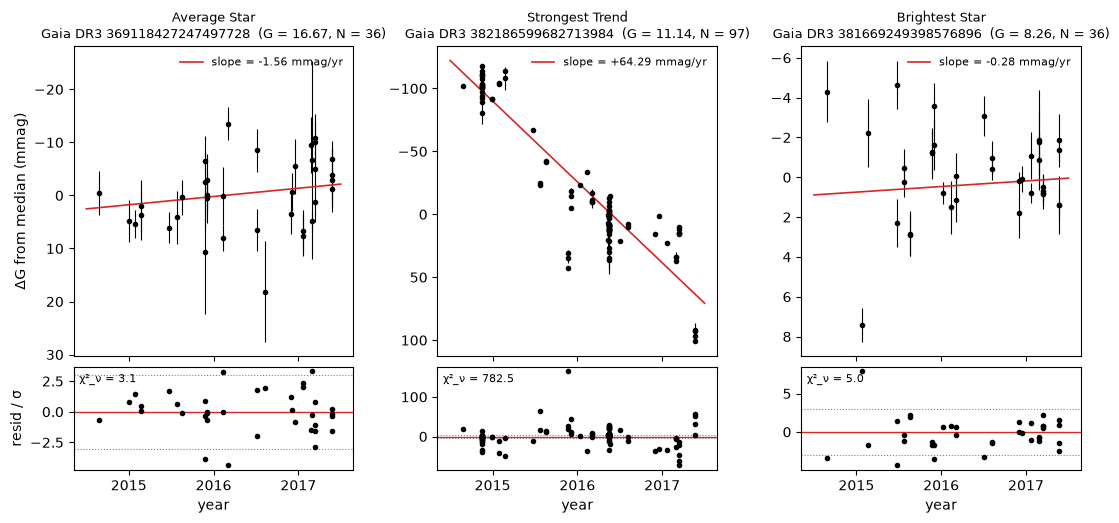

In [13]:
# Task 2: three light curves with fits and residual panels (uses df, ids, start, n, g_med, T0 from cell 1)

def star(i):
    s = df[start[i]:start[i] + n[i]]
    return s["t_year"], s["gmag"], s["gmag_err"]

# --- Quick per-star diagnostics, only used to choose the three stars ---
chi2_const, slope_z = np.empty(len(ids)), np.empty(len(ids))
for i in range(len(ids)):
    t, m, e = star(i)
    w = 1 / e**2
    mbar = np.sum(w * m) / np.sum(w)
    chi2_const[i] = np.sum(w * (m - mbar)**2) / (n[i] - 1)       # reduced chi2 of a flat line
    p, C = np.polyfit(t - T0, m, 1, w=1 / e, cov="unscaled")
    slope_z[i] = p[0] / np.sqrt(C[0, 0])

picks = {
    "Average Star": np.argsort(chi2_const)[len(ids) // 2],        # median flat-line chi2
    "Strongest Trend": np.argmax(np.abs(slope_z)),
    "Brightest Star": np.argmin(g_med),                           # where an error floor bites hardest
}

# --- Figure: 3 columns, light curve on top, normalized residuals below ---
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.3})
tt = np.linspace(2014.5, 2017.5, 200)

for col, (label, i) in enumerate(picks.items()):
    t, m, e = star(i)
    ref = np.median(m)
    dm = 1e3 * (m - ref)                      # plot in mmag relative to median
    p = np.polyfit(t - T0, m, 1, w=1 / e)
    resid = (m - np.polyval(p, t - T0)) / e   # residuals in units of the quoted error
    chi2r = np.sum(resid**2) / (len(t) - 2)

    top, bot = axes[0, col], axes[1, col]
    top.errorbar(t, dm, yerr=1e3 * e, fmt="o", color="k", ms=3, elinewidth=0.8, capsize=0)
    top.plot(tt, 1e3 * (np.polyval(p, tt - T0) - ref), color="C3", lw=1.2,
             label=f"slope = {1e3*p[0]:+.2f} mmag/yr")
    top.invert_yaxis()                        # brighter = up
    top.set_title(f"{label}\nGaia DR3 {ids[i]}  (G = {ref:.2f}, N = {len(t)})", fontsize=9)
    top.set_ylabel("ΔG from median (mmag)" if col == 0 else "")
    top.legend(fontsize=8, loc="best", frameon=False)

    bot.axhline(0, color="C3", lw=1)
    for k in (-3, 3):
        bot.axhline(k, color="grey", ls=":", lw=0.8)
    bot.plot(t, resid, "o", color="k", ms=3)
    bot.set_ylabel("resid / σ" if col == 0 else "")
    bot.set_xlabel("year")
    bot.text(0.02, 0.85, f"χ²_ν = {chi2r:.1f}", transform=bot.transAxes, fontsize=8)

fig.savefig("task2_lightcurves.pdf", bbox_inches="tight")
print({k: int(ids[i]) for k, i in picks.items()})

3. For one star: unweighted fit of m(t) with np.polyfit.

In [14]:
# Let's pick strongest trend - Gaia DR3 382186599682713984
sid = 382186599682713984
s = df[df["source_id"] == sid]
order = np.argsort(s["t_year"], kind="stable")
# sorts every column together
s = s[order]

t = s["t_year"] - 2016.0
m = s["gmag"]
e = s["gmag_err"]

slope, intercept = np.polyfit(t, m, 1)   # unweighted: no w=
resid = m - np.polyval([slope, intercept], t)
sig_slope = resid.std(ddof=2) / np.sqrt(np.sum((t - t.mean())**2))

print(f"N = {len(t)}  slope = {1e3*slope:+.2f} ± {1e3*sig_slope:.2f} mmag/yr  "
      f"G(2016.0) = {intercept:.4f}  rms resid = {1e3*resid.std(ddof=2):.2f} mmag")

N = 97  slope = +65.37 ± 2.80 mmag/yr  G(2016.0) = 11.1194  rms resid = 21.42 mmag


4. Write your own code solving the weighted normal equations; check you
reproduce polyfit exactly.

In [15]:
def wls(t, m, e):
    A = np.column_stack([t, np.ones_like(t)])
    w = 1.0 / e**2
    ATWA = A.T @ (A * w[:, None])
    C = np.linalg.inv(ATWA)
    beta = np.linalg.solve(ATWA, A.T @ (w * m))
    return beta, C          # beta = [slope, intercept]

In [16]:
beta, C = wls(t, m, e)
p, Cp = np.polyfit(t, m, 1, w=1/e, cov="unscaled")
print(np.max(np.abs(beta - p)), np.max(np.abs(C - Cp)))

1.0200174038743626e-14 3.308722450212111e-24


5. Now the production run: weighted fit with covariance for every star (a loop over
2,025 regressions). Save slope si and its error σi from the covariance diagonal.


In [17]:
def fit_all(f=0.0, perms=None):
    s, sig = np.empty(N), np.empty(N)
    for i, (a, k) in enumerate(zip(start, n)):
        r = df[a:a+k]
        m, e = r["gmag"], np.sqrt(r["gmag_err"]**2 + f**2)
        if perms is not None:
            m, e = m[perms[i]], e[perms[i]]   # shuffle (mag, err) pairs vs. time
        beta, C = wls(r["t_year"] - T0, m, e)
        s[i], sig[i] = beta[0], np.sqrt(C[0, 0])
    return s, sig

slopes, sig = fit_all()
z = slopes / sig

6. Histogram of zi = si/σi. If no star truly varied and the errors were correct, what
distribution must this be? Overplot it

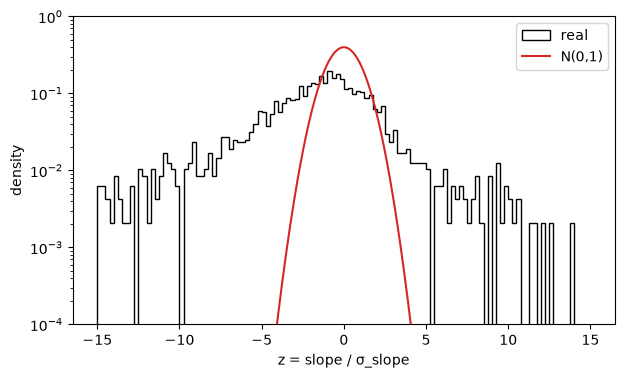

robust width = 2.97   |z|>3: 760  (expect 5.5 if errors correct)


In [18]:
def rwidth(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

bins = np.linspace(-15, 15, 121)
x = np.linspace(-15, 15, 500)
plt.figure(figsize=(7, 4))
plt.hist(z, bins, density=True, histtype="step", color="k", label="real")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0,1)")
plt.yscale("log"); plt.ylim(1e-4, 1)
plt.xlabel("z = slope / σ_slope"); plt.ylabel("density"); plt.legend()
plt.show()
print(f"robust width = {rwidth(z):.2f}   |z|>3: {np.sum(np.abs(z) > 3)}  (expect {0.0027*N:.1f} if errors correct)")


7. The control experiment. For each star, randomly shuffle its magnitudes relative
to its times (np.random.permutation) and refit. Overplot the shuffled z histogram on
the real one. Shuffling destroys any true time-dependence — so what does it mean
that the shuffled histogram is also much wider than your prediction from task 6?

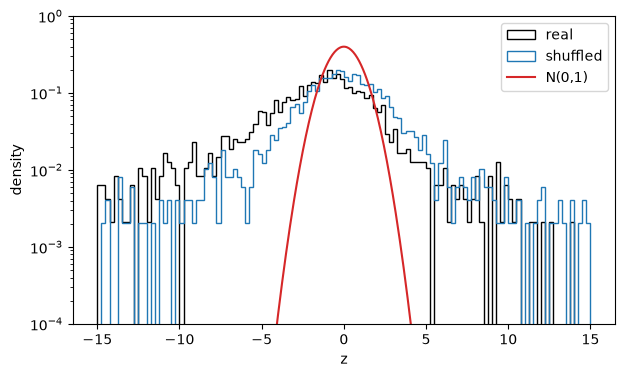

robust width: real 2.97, shuffled 2.38
sig unchanged by shuffle: False


In [19]:
rng = np.random.default_rng(42)
perms = [rng.permutation(k) for k in n]     # generate once, reuse in task 8
s_sh, sig_sh = fit_all(perms=perms)
z_sh = s_sh / sig_sh

plt.figure(figsize=(7, 4))
plt.hist(z, bins, density=True, histtype="step", color="k", label="real")
plt.hist(z_sh, bins, density=True, histtype="step", color="C0", label="shuffled")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0,1)")
plt.yscale("log"); plt.ylim(1e-4, 1)
plt.xlabel("z"); plt.ylabel("density"); plt.legend()
plt.show()
print(f"robust width: real {rwidth(z):.2f}, shuffled {rwidth(z_sh):.2f}")
print("sig unchanged by shuffle:", np.allclose(sig, sig_sh))


8. Fix the error bars. Using only the shuffled fits, find the constant f (mmag) that,
added in quadrature to every gmag_err, makes the shuffled z width equal 1. Redo
task 6 with corrected errors: how many stars now show real (|z| > 3) slopes? expect f
of a few mmag — this is Gaia’s known calibration floor, which photon noise ignores

g(0) = +1.38, g(0.05) = -0.91   (need opposite signs)
f = 3.33 mmag


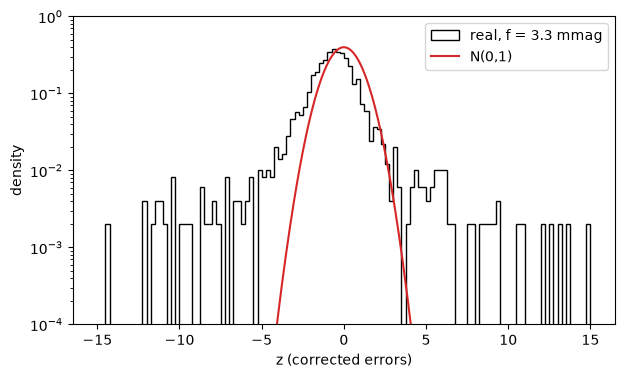

robust width = 1.18   |z|>3: 238  (expect 5.5 by chance)


In [20]:
def g(f):
    s_, sg_ = fit_all(f=f, perms=perms)
    return rwidth(s_ / sg_) - 1.0

print(f"g(0) = {g(0.0):+.2f}, g(0.05) = {g(0.05):+.2f}   (need opposite signs)")
f_best = scipy.optimize.brentq(g, 0.0, 0.05)    # mag
print(f"f = {1e3*f_best:.2f} mmag")

s_c, sig_c = fit_all(f=f_best)
z_c = s_c / sig_c
plt.figure(figsize=(7, 4))
plt.hist(z_c, bins, density=True, histtype="step", color="k", label=f"real, f = {1e3*f_best:.1f} mmag")
plt.plot(x, scipy.stats.norm.pdf(x), "C3", label="N(0,1)")
plt.yscale("log"); plt.ylim(1e-4, 1)
plt.xlabel("z (corrected errors)"); plt.ylabel("density"); plt.legend()
plt.show()
print(f"robust width = {rwidth(z_c):.2f}   |z|>3: {np.sum(np.abs(z_c) > 3)}  (expect {0.0027*N:.1f} by chance)")


9. Bias hunt. Compute the median slope of the population and bootstrap its
uncertainty. Can 2,000 randomly chosen stars share a nonzero net drift
astrophysically? Test at least one instrumental hypothesis (e.g. refit excluding all
epochs before 2015.5; or median slope vs. G).

In [21]:
B = 5000
idx = rng.integers(0, N, size=(B, N))
boot = np.median(s_c[idx], axis=1)
med, err = np.median(s_c), boot.std()
print(f"median slope = {1e3*med:+.3f} ± {1e3*err:.3f} mmag/yr  ({med/err:.1f}σ)")

median slope = -0.454 ± 0.019 mmag/yr  (-23.7σ)
